## Customer Churn Analysis project

In [2]:
import pandas as pd # for data manipulation

In [3]:
# visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [4]:
# Warnings
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

## Time to load the dataset

In [5]:
file_path = 'C:/Users/HomePC/Downloads/Customer_Churn_Data_Large.xlsx'
df = pd.read_excel(file_path, sheet_name="Customer_Demographics")

In [6]:
df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium
...,...,...,...,...,...
995,996,54,F,Single,Low
996,997,19,M,Widowed,High
997,998,47,M,Married,Low
998,999,23,M,Widowed,High


In [7]:
file_path = 'C:/Users/HomePC/Downloads/Customer_Churn_Data_Large.xlsx'
df1 = pd.read_excel(file_path, sheet_name="Transaction_History")

In [8]:
df1

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing
...,...,...,...,...,...
5049,1000,2724,2022-09-08,232.06,Groceries
5050,1000,2917,2022-12-13,324.98,Books
5051,1000,2979,2022-06-15,375.34,Groceries
5052,1000,8594,2022-04-08,166.73,Books


In [9]:
file_path = 'C:/Users/HomePC/Downloads/Customer_Churn_Data_Large.xlsx'
df2 = pd.read_excel(file_path, sheet_name="Customer_Service")
df2

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved
...,...,...,...,...,...
997,990,3671,2022-10-25,Complaint,Unresolved
998,992,2114,2022-09-29,Feedback,Unresolved
999,994,3087,2022-07-02,Complaint,Unresolved
1000,994,8508,2022-05-14,Complaint,Unresolved


In [10]:
file_path = 'C:/Users/HomePC/Downloads/Customer_Churn_Data_Large.xlsx'
df3 = pd.read_excel(file_path, sheet_name="Online_Activity")
df3

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website
...,...,...,...,...
995,996,2023-01-29,38,Mobile App
996,997,2023-04-01,5,Mobile App
997,998,2023-07-10,47,Website
998,999,2023-01-08,23,Website


In [11]:
file_path = 'C:/Users/HomePC/Downloads/Customer_Churn_Data_Large.xlsx'
df4 = pd.read_excel(file_path, sheet_name="Churn_Status")

In [12]:
df4

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0
...,...,...
995,996,0
996,997,0
997,998,0
998,999,0


In [13]:
# To run agg on Transactions data
file_path = 'C:/Users/HomePC/Downloads/Customer_Churn_Data_Large.xlsx'

transactions = pd.read_excel(file_path, sheet_name="Transaction_History")

In [14]:
# Aggregate Transaction Data as each customer has more than one entity

transaction_agg = transactions.groupby("CustomerID").agg(
    TotalAmountSpent=("AmountSpent", "sum"),
    TransactionCount=("TransactionID", "count"),
    LastTransactionDate=("TransactionDate", "max")
).reset_index()

In [15]:
# run agg on customer data
file_path = 'C:/Users/HomePC/Downloads/Customer_Churn_Data_Large.xlsx'

service = pd.read_excel(file_path, sheet_name="Customer_Service")

In [16]:
# Aggregate Customer_service
service_agg = service.groupby("CustomerID").agg(
    ServiceInteractionCount=("InteractionID", "count"),
    UnresolvedIssues=("ResolutionStatus", lambda x: (x == "Unresolved").sum())
).reset_index()

In [17]:

# declare all the variables for merging
file_path = 'C:/Users/HomePC/Downloads/Customer_Churn_Data_Large.xlsx'

demographics = pd.read_excel(file_path, sheet_name="Customer_Demographics")
transactions = pd.read_excel(file_path, sheet_name="Transaction_History")
service = pd.read_excel(file_path, sheet_name="Customer_Service")
churn = pd.read_excel(file_path, sheet_name="Churn_Status")

In [18]:
# Merge the datasets
df = demographics.merge(transaction_agg, on="CustomerID", how="left")
df = df.merge(service_agg, on="CustomerID", how="left")
df = df.merge(churn, on="CustomerID", how="left")


print(df.head())

   CustomerID  Age Gender MaritalStatus IncomeLevel  TotalAmountSpent  \
0           1   62      M        Single         Low            416.50   
1           2   65      M       Married         Low           1547.42   
2           3   18      M        Single         Low           1702.98   
3           4   21      M       Widowed         Low            917.29   
4           5   21      M      Divorced      Medium           2001.49   

   TransactionCount LastTransactionDate  ServiceInteractionCount  \
0                 1          2022-03-27                      1.0   
1                 7          2022-11-19                      1.0   
2                 6          2022-10-08                      1.0   
3                 5          2022-12-27                      2.0   
4                 8          2022-12-21                      NaN   

   UnresolvedIssues  ChurnStatus  
0               0.0            0  
1               0.0            1  
2               0.0            0  
3           

In [19]:
print(df.tail())

     CustomerID  Age Gender MaritalStatus IncomeLevel  TotalAmountSpent  \
995         996   54      F        Single         Low            227.25   
996         997   19      M       Widowed        High            419.82   
997         998   47      M       Married         Low            252.15   
998         999   23      M       Widowed        High           2393.26   
999        1000   34      M       Widowed         Low           1670.79   

     TransactionCount LastTransactionDate  ServiceInteractionCount  \
995                 1          2022-07-24                      NaN   
996                 2          2022-10-25                      NaN   
997                 1          2022-09-18                      NaN   
998                 9          2022-12-07                      NaN   
999                 6          2022-12-13                      NaN   

     UnresolvedIssues  ChurnStatus  
995               NaN            0  
996               NaN            0  
997              

In [20]:
 print(df.shape)

(1000, 11)


In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CustomerID               1000 non-null   int64         
 1   Age                      1000 non-null   int64         
 2   Gender                   1000 non-null   object        
 3   MaritalStatus            1000 non-null   object        
 4   IncomeLevel              1000 non-null   object        
 5   TotalAmountSpent         1000 non-null   float64       
 6   TransactionCount         1000 non-null   int64         
 7   LastTransactionDate      1000 non-null   datetime64[ns]
 8   ServiceInteractionCount  668 non-null    float64       
 9   UnresolvedIssues         668 non-null    float64       
 10  ChurnStatus              1000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(3)
memory usage: 86.1+ KB
None


In [22]:
print(df.describe())


        CustomerID          Age  TotalAmountSpent  TransactionCount  \
count  1000.000000  1000.000000       1000.000000       1000.000000   
mean    500.500000    43.267000       1267.074950          5.054000   
min       1.000000    18.000000          9.800000          1.000000   
25%     250.750000    30.000000        626.685000          3.000000   
50%     500.500000    43.000000       1232.880000          5.000000   
75%     750.250000    56.000000       1791.902500          7.000000   
max    1000.000000    69.000000       3386.040000          9.000000   
std     288.819436    15.242311        738.590013          2.603433   

              LastTransactionDate  ServiceInteractionCount  UnresolvedIssues  \
count                        1000               668.000000        668.000000   
mean   2022-10-13 22:46:33.600000                 1.500000          0.717066   
min           2022-01-10 00:00:00                 1.000000          0.000000   
25%           2022-09-16 00:00:00       

In [ ]:
#("Missing values before cleaning:")
print(df.isnull().sum())

CustomerID                   0
Age                          0
Gender                       0
MaritalStatus                0
IncomeLevel                  0
TotalAmountSpent             0
TransactionCount             0
LastTransactionDate          0
ServiceInteractionCount    332
UnresolvedIssues           332
ChurnStatus                  0
dtype: int64


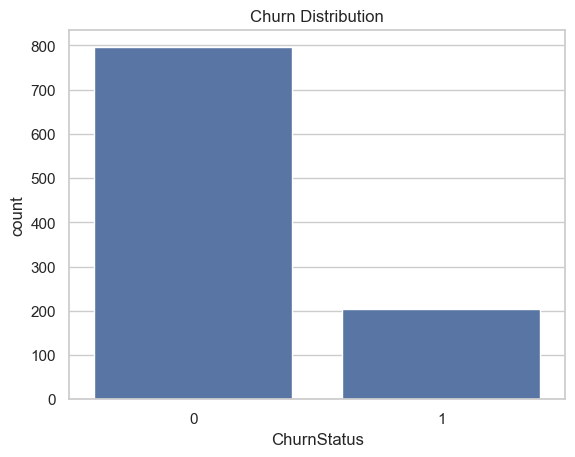

In [24]:

# CHURN DISTRIBUTION

sns.countplot(data=df, x="ChurnStatus")
plt.title("Churn Distribution")
plt.show()

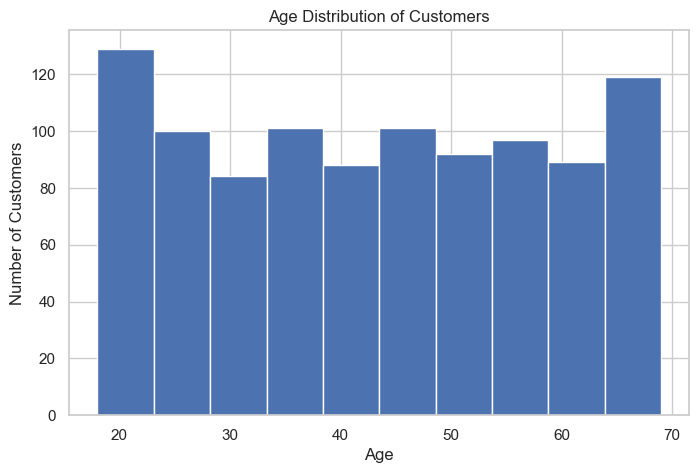

In [25]:
# AGE DISTRIBUTION
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution of Customers")
plt.show()

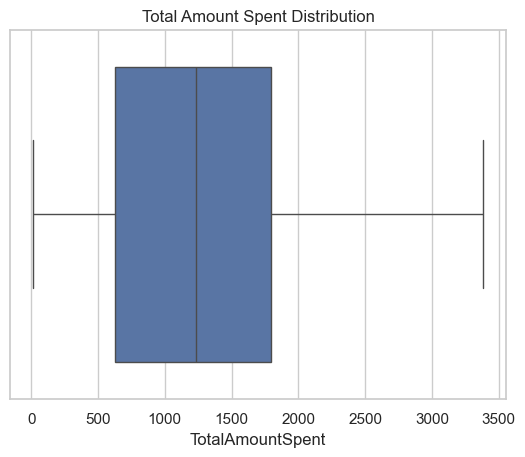

In [26]:
# TOTAL AMOUNT SPENT

sns.boxplot(x=df["TotalAmountSpent"])
plt.title("Total Amount Spent Distribution")
plt.show()

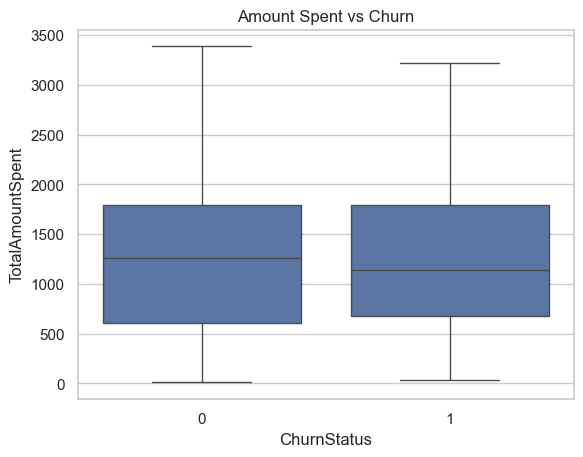

In [27]:
# Amount vs churn

sns.boxplot(data=df, x="ChurnStatus", y="TotalAmountSpent")
plt.title("Amount Spent vs Churn")
plt.show()

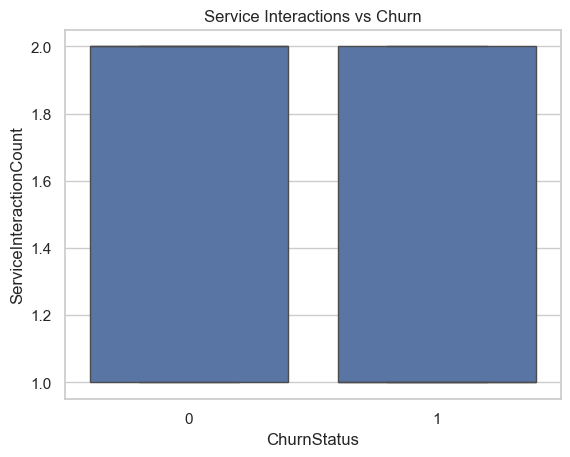

In [28]:
# Service interraction vs churn

sns.boxplot(data=df, x="ChurnStatus", y="ServiceInteractionCount")
plt.title("Service Interactions vs Churn")
plt.show()

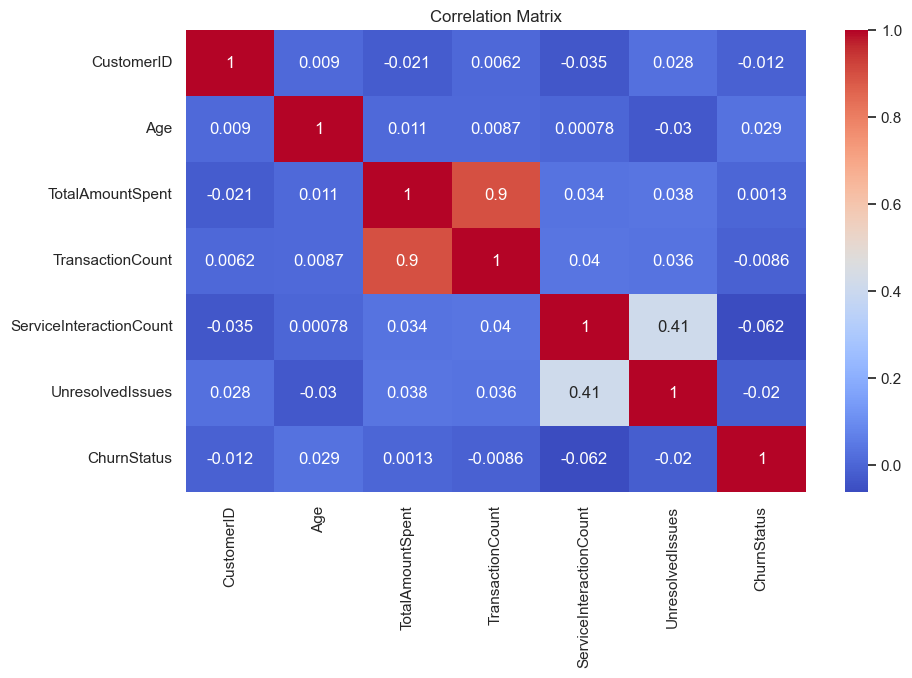

In [29]:

# Correlation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

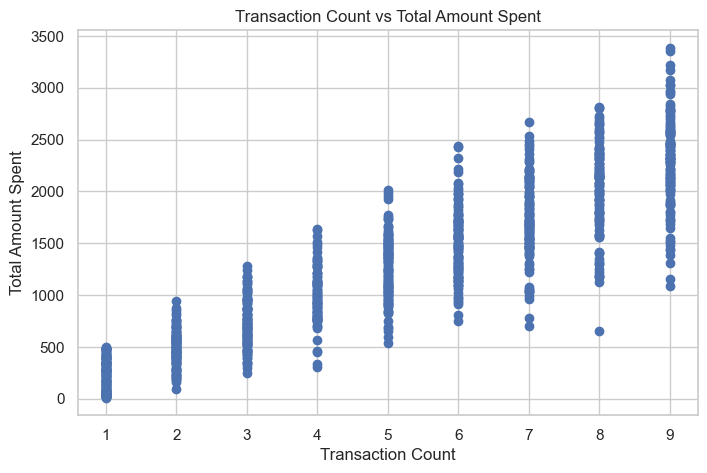

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df["TransactionCount"], df["TotalAmountSpent"])
plt.xlabel("Transaction Count")
plt.ylabel("Total Amount Spent")
plt.title("Transaction Count vs Total Amount Spent")
plt.show()

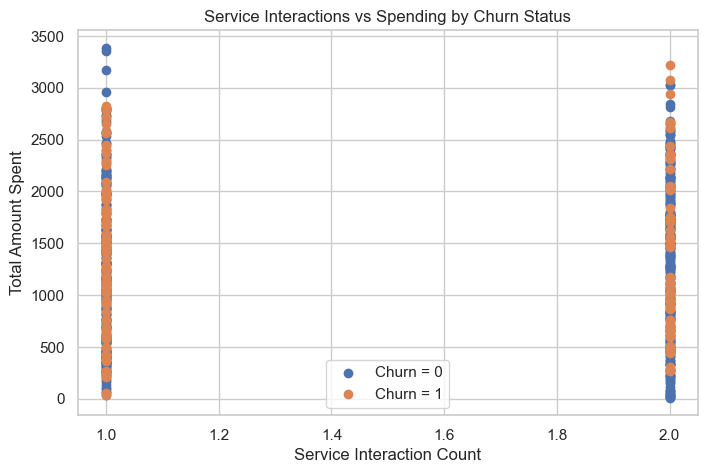

In [31]:
plt.figure(figsize=(8,5))

for churn_value in df["ChurnStatus"].unique():
    subset = df[df["ChurnStatus"] == churn_value]
    plt.scatter(
        subset["ServiceInteractionCount"],
        subset["TotalAmountSpent"],
        label=f"Churn = {churn_value}"
    )

plt.xlabel("Service Interaction Count")
plt.ylabel("Total Amount Spent")
plt.title("Service Interactions vs Spending by Churn Status")
plt.legend()
plt.show()

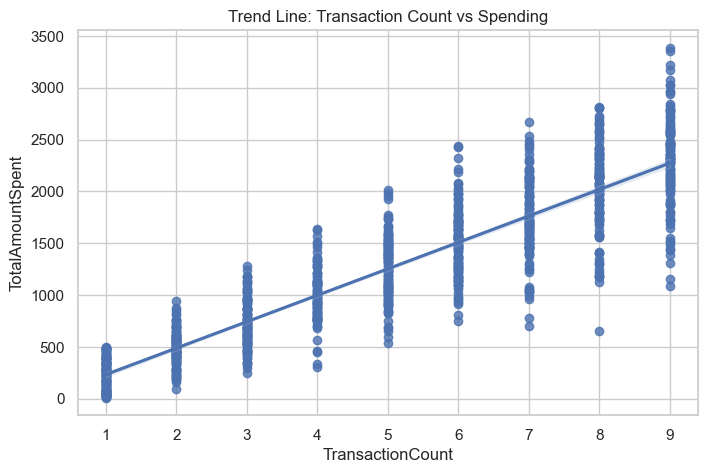

In [32]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x="TransactionCount",
    y="TotalAmountSpent",
    scatter=True
)

plt.title("Trend Line: Transaction Count vs Spending")
plt.show()

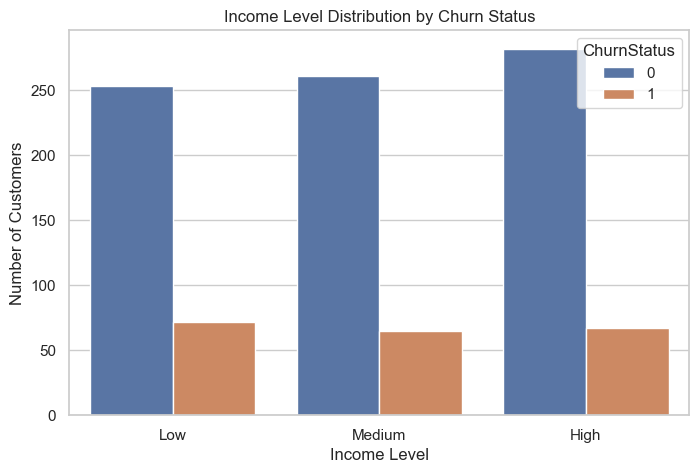

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="IncomeLevel", hue="ChurnStatus")

plt.xlabel("Income Level")
plt.ylabel("Number of Customers")
plt.title("Income Level Distribution by Churn Status")
plt.show()

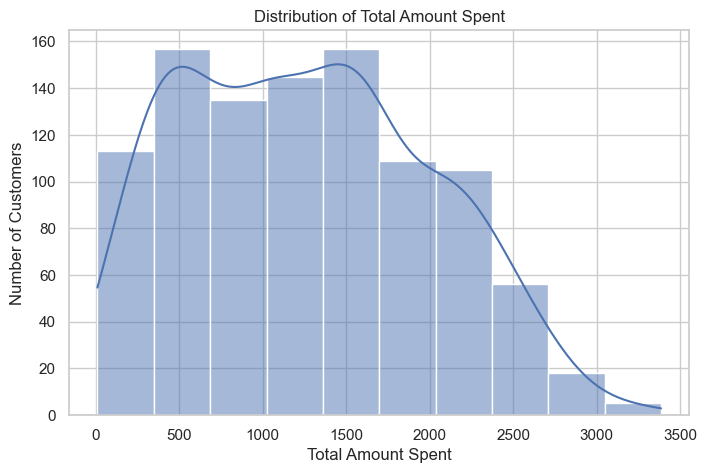

In [34]:
# Total Amount spent
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["TotalAmountSpent"], bins=10, kde=True)

plt.xlabel("Total Amount Spent")
plt.ylabel("Number of Customers")
plt.title("Distribution of Total Amount Spent")
plt.show()

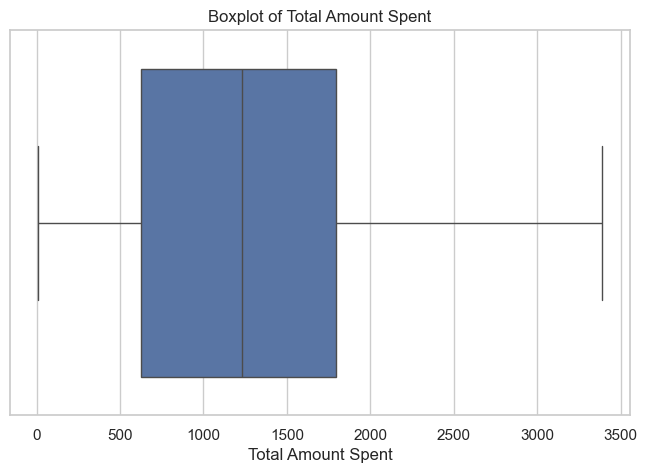

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalAmountSpent"])

plt.xlabel("Total Amount Spent")
plt.title("Boxplot of Total Amount Spent")
plt.show()

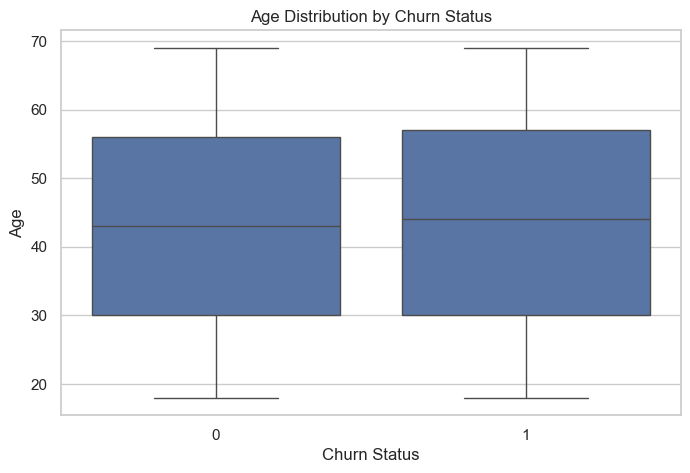

In [36]:
# Age vs churn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="ChurnStatus", y="Age")

plt.xlabel("Churn Status")
plt.ylabel("Age")
plt.title("Age Distribution by Churn Status")
plt.show()

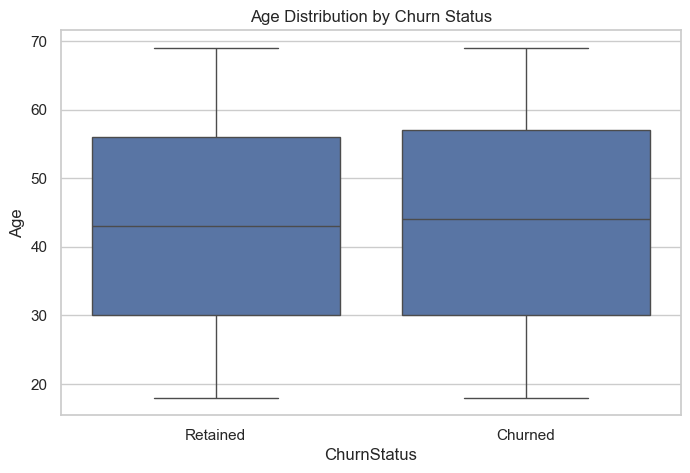

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="ChurnStatus", y="Age")

plt.xticks([0,1], ["Retained", "Churned"])
plt.title("Age Distribution by Churn Status")
plt.show()

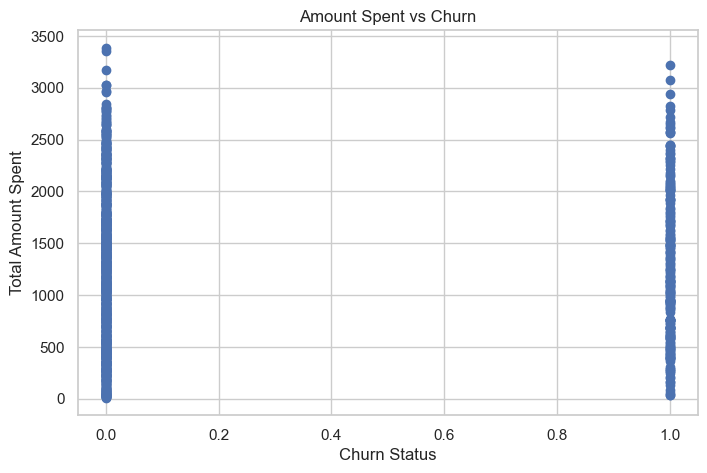

In [38]:
# Amnt spent vs Churn

plt.figure(figsize=(8,5))
plt.scatter(df["ChurnStatus"], df["TotalAmountSpent"])

plt.xlabel("Churn Status")
plt.ylabel("Total Amount Spent")
plt.title("Amount Spent vs Churn")
plt.show()

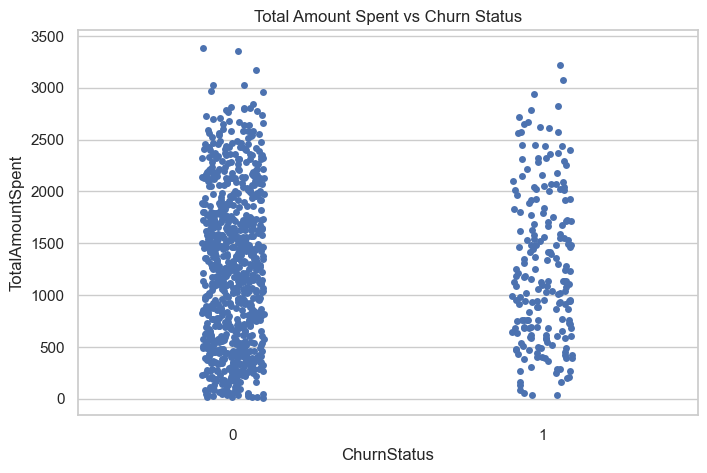

In [39]:

plt.figure(figsize=(8,5))
sns.stripplot(data=df, x="ChurnStatus", y="TotalAmountSpent", jitter=True)

plt.title("Total Amount Spent vs Churn Status")
plt.show()

In [40]:
df.columns = df.columns.str.strip()

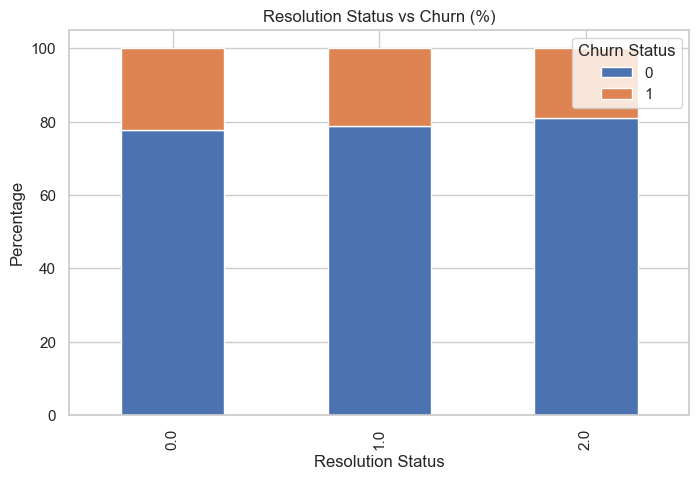

In [41]:
# A ResUnresolvedIssues vs Churn 
resolution_percent = pd.crosstab(
    df["UnresolvedIssues"],
    df["ChurnStatus"],
    normalize="index"
) * 100

resolution_percent.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Resolution Status vs Churn (%)")
plt.ylabel("Percentage")
plt.xlabel("Resolution Status")
plt.legend(title="Churn Status")
plt.show()

In [42]:
print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'TotalAmountSpent', 'TransactionCount', 'LastTransactionDate',
       'ServiceInteractionCount', 'UnresolvedIssues', 'ChurnStatus'],
      dtype='object')


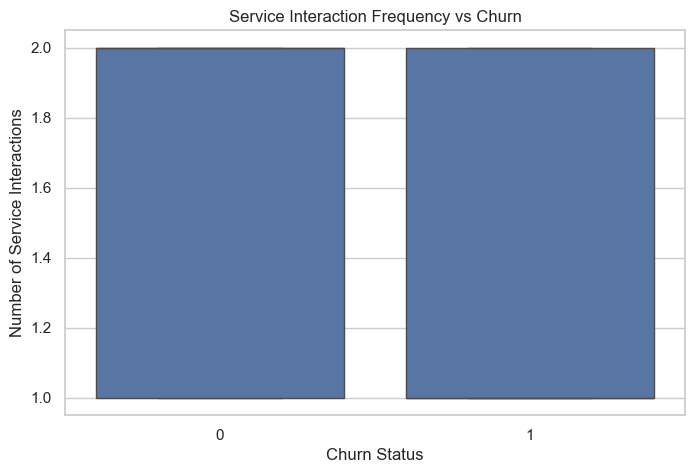

In [43]:
# Interraction frequency

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="ChurnStatus", y="ServiceInteractionCount")

plt.title("Service Interaction Frequency vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Service Interactions")
plt.show()

In [44]:
# Data Cleaning
# Handle data missing
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

CustomerID                 0
Age                        0
Gender                     0
MaritalStatus              0
IncomeLevel                0
TotalAmountSpent           0
TransactionCount           0
LastTransactionDate        0
ServiceInteractionCount    0
UnresolvedIssues           0
ChurnStatus                0
dtype: int64


In [51]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
CustomerID                 0
Age                        0
Gender                     0
MaritalStatus              0
IncomeLevel                0
TotalAmountSpent           0
TransactionCount           0
LastTransactionDate        0
ServiceInteractionCount    0
UnresolvedIssues           0
ChurnStatus                0
HighServiceIssueFlag       0
AvgTransactionValue        0
dtype: int64


In [ ]:
# For Outlier (IQR METHOD)
def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[column] = np.where(df[column] > upper, upper,
                          np.where(df[column] < lower, lower, df[column]))

# Apply to financial columns
cap_outliers("TotalAmountSpent")
cap_outliers("TransactionCount")

In [ ]:
# Feature Engineering
# Create High Risk Flag 
df["HighServiceIssueFlag"] = np.where(df["UnresolvedIssues"] > 0, 1, 0)

# Customer Value Metric
df["AvgTransactionValue"] = df["TotalAmountSpent"] / df["TransactionCount"]

In [47]:
# Scale Numeral 
scaler = StandardScaler()

scale_cols = ["Age", "TotalAmountSpent", "TransactionCount",
              "ServiceInteractionCount", "UnresolvedIssues",
              "AvgTransactionValue"]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [48]:
#final data set for modelling
# Drop ID column before modeling
final_df = df.drop(columns=["CustomerID", "LastTransactionDate"])

print(final_df.head())
print(final_df.shape)

        Age Gender MaritalStatus IncomeLevel  TotalAmountSpent  \
0  1.229628      M        Single         Low         -1.152196   
1  1.426547      M       Married         Low          0.379758   
2 -1.658518      M        Single         Low          0.590481   
3 -1.461599      M       Widowed         Low         -0.473822   
4 -1.461599      M      Divorced      Medium          0.994845   

   TransactionCount  ServiceInteractionCount  UnresolvedIssues  ChurnStatus  \
0         -1.557954                -1.223522         -1.507865            0   
1          0.747849                -1.223522         -1.507865            1   
2          0.363548                -1.223522         -1.507865            0   
3         -0.020752                 1.223522          0.351401            0   
4          1.132149                 0.000000          0.351401            0   

   HighServiceIssueFlag  AvgTransactionValue  
0                     0             2.113790  
1                     0           

In [49]:
final_df.to_csv("cleaned_churn_dataset.csv", index=False)